# Rateio de Custos da Pilares - Faturamento X Head

Este notebook le os lancamentos do CSV mensal (`Pilares_{Mes}.CSV`), soma **Valor Oficial**, aplica o criterio **Faturamento X Head** e gera o grafico de pizza no padrao da controladoria.

## Uso mensal

1. Exporte/coloque o arquivo em `02-Referencias/Meus_Dados/` com o nome no padrao `Pilares_Abril.CSV`, `Pilares_Maio.CSV`, etc.
2. Na celula **Configuracao mensal**, altere apenas `NOME_MES` para coincidir com o arquivo (`"Abril"`, `"Maio"`, ...).
3. Execute todas as celulas (**Run All**).

Saidas geradas (raiz do projeto): `outputs/graficos/` (PNG) e `outputs/tabelas/` (Excel).

## Logica aplicada
- `score = percentual_faturamento * percentual_head`
- `participacao = score / soma(score)`
- `valor_rateado = valor_total * participacao`


In [18]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from IPython.display import display

plt.style.use('default')

## Configuracao mensal

### Padrao do arquivo de lancamentos

| Arquivo na pasta `Meus_Dados` | Valor de `NOME_MES` |
| --- | --- |
| `Pilares_Marco.CSV` | `"Marco"` |
| `Pilares_Abril.CSV` | `"Abril"` |

Nome gerado pelo notebook: `Pilares_{NOME_MES}.CSV`

Se um dia o nome mudar (ex.: prefixo diferente), ajuste `PADRAO_NOME_ARQUIVO` na celula seguinte.

In [19]:
# ========= CONFIGURACAO MENSAL (editar todo mes) =========
NOME_MES = "Março"

# Pasta dentro de 02-Referencias/
PASTA_MEUS_DADOS = "Meus_Dados"

# Padrao do nome do arquivo: use {mes} como placeholder
PADRAO_NOME_ARQUIVO = "Pilares_{mes}.CSV"
# ========================================================

## 2) Entrada de dados

- **Lançamentos:** o caminho vem da config acima: `02-Referencias/Meus_Dados/` + `Pilares_{NOME_MES}.CSV` (sep `;`). O total rateável é a **soma da coluna `Valor Oficial`**.
- **Pesos Faturamento × Head:** tabela `df` com colunas `grupo`, `percentual_faturamento`, `percentual_head` (ajuste os percentuais conforme o fechamento).

Os percentuais podem vir em escala 0-100 (ex.: 76) ou 0-1 (ex.: 0.76).

In [20]:
def _resolver_raiz_projeto() -> Path:
    cwd = Path.cwd()
    if (cwd / "02-Referencias").is_dir():
        return cwd
    if (cwd.parent / "02-Referencias").is_dir():
        return cwd.parent
    if (cwd.parent.parent / "02-Referencias").is_dir():
        return cwd.parent.parent
    return cwd


def parse_valor_oficial(valor) -> float:
    """Converte strings tipo '-R$ 50.000,00' ou '-50.000,00' para float."""
    if pd.isna(valor) or str(valor).strip() == "":
        return float("nan")
    s = str(valor).strip().replace("\xa0", " ")
    for token in ("R$", "r$"):
        s = s.replace(token, "")
    s = s.replace(" ", "").replace(".", "").replace(",", ".")
    return float(s)


ROOT = _resolver_raiz_projeto()
_ARQUIVO_CSV = PADRAO_NOME_ARQUIVO.format(mes=NOME_MES)
CAMINHO_LANCAMENTOS = ROOT / "02-Referencias" / PASTA_MEUS_DADOS / _ARQUIVO_CSV

if not CAMINHO_LANCAMENTOS.is_file():
    raise FileNotFoundError(
        f"Arquivo nao encontrado: {CAMINHO_LANCAMENTOS}\n"
        f"Ajuste NOME_MES ou exporte o CSV para Meus_Dados."
    )

_buf = CAMINHO_LANCAMENTOS.read_bytes()
_encoding = "utf-8-sig"
for enc in ("utf-8-sig", "cp1252", "latin-1"):
    try:
        _buf.decode(enc)
        _encoding = enc
        break
    except UnicodeDecodeError:
        continue

print(f"Encoding detectado: {_encoding}")

lancamentos = pd.read_csv(
    CAMINHO_LANCAMENTOS,
    sep=";",
    encoding=_encoding,
    dtype=str,
    engine="python",
)
lancamentos.columns = lancamentos.columns.str.strip()

col_oficial = next(
    (c for c in lancamentos.columns if "valor" in c.lower() and "oficial" in c.lower()),
    None,
)
if col_oficial is None:
    raise ValueError(
        "Coluna 'Valor Oficial' nao encontrada. Colunas: " + str(list(lancamentos.columns))
    )

lancamentos["_valor_oficial_num"] = lancamentos[col_oficial].map(parse_valor_oficial)
valor_total = lancamentos["_valor_oficial_num"].sum()

print(f"Arquivo: {CAMINHO_LANCAMENTOS}")
print(f"Linhas: {len(lancamentos)} | Coluna somada: {col_oficial!r}")
print(f"Valor total (soma Valor Oficial): {valor_total:,.2f}")

# Pesos Faturamento x Head (ajuste conforme o fechamento)
df = pd.DataFrame(
    {
        "grupo": ["BRACOFER", "EKIPA", "SELETIVA", "TRANSMOVE GSL"],
        "percentual_faturamento": [18, 2, 72, 8],
        "percentual_head": [14, 1, 80, 5],
    }
)

display(lancamentos.head(3))
df

Encoding detectado: cp1252
Arquivo: c:\Users\julio.santana\Documents\Projects\Cofre_Trabalho\02-Referencias\Meus_Dados\Pilares_Março.CSV
Linhas: 123 | Coluna somada: 'Valor Oficial'
Valor total (soma Valor Oficial): -226,515.49


,sdssds,n1_cod_centro_custo,n1_centro_custo,n1_CC,n2_cod_centro_custo,n2_centro_custo,n2_CC,n3_cod_centro_custo,n3_centro_custo,n3_CC,...,observacao,data_nf,data_pagamento,cod_credor_forn_cli_func,credor_forn_cli_func,Origem,Sistema,Dados auxiliares,Valor Oficial,_valor_oficial_num
0,PILARES,1.1,PILARES,1.1 PILARES,1.1.1.1,DIRETORIA,1.1.1.1 DIRETORIA,1.1.1.1,ACIONISTAS,1.1.1.1 ACIONISTAS,...,REFERENTE A CONTRATO DE MUTUO EM 03/03/2026 N...,03/03/2026,2026-03-03,180,RENATO JOSE APARECIDO SALTEIRO,Saida (Aplicacoes),SAGI,NaN,"-R$ 50.000,00",-50000.0
1,PILARES,1.1,PILARES,1.1 PILARES,1.1.5,QUALIDADE,1.1.5 QUALIDADE,1.1.5,QUALIDADE,1.1.5 QUALIDADE,...,[GIULIANA] REF AOS SERVIÇOS PRESTADOS POR LUC...,02/03/2026,2026-03-05,23476,SILVA & FARIAS TREINAMENTOS LTDA,Saida (Aplicacoes),SAGI,7-E/NS,"-R$ 2.640,00",-2640.0
2,PILARES,1.1,PILARES,1.1 PILARES,1.10.1,OPERACOES ENTRE EMPRESA,1.10.1 OPERACOES ENTRE EMPRESA,1.10.1,OPERACOES ENTRE EMPRESA,1.10.1 OPERACOES ENTRE EMPRESA,...,REFERENTE A TESTE TERMINAL,23/03/2026,2026-03-23,121,BANCO COOPERATIVO SICREDI SA,Saida (Aplicacoes),SAGI,NaN,"R$ 1,00",1.0


,grupo,percentual_faturamento,percentual_head
0,BRACOFER,18,14
1,EKIPA,2,1
2,SELETIVA,72,80
3,TRANSMOVE GSL,8,5


In [21]:
def normalizar_percentual(coluna: pd.Series) -> pd.Series:
    """Converte escala 0-100 para 0-1 quando necessario."""
    c = coluna.astype(float)
    return c / 100.0 if c.max() > 1 else c


def calcular_rateio_faturamento_x_head(
    base: pd.DataFrame,
    coluna_grupo: str = "grupo",
    coluna_fat: str = "percentual_faturamento",
    coluna_head: str = "percentual_head",
    total: float = 0.0,
) -> pd.DataFrame:
    tmp = base.copy()
    tmp[coluna_fat] = normalizar_percentual(tmp[coluna_fat])
    tmp[coluna_head] = normalizar_percentual(tmp[coluna_head])

    tmp["score_fxh"] = tmp[coluna_fat] * tmp[coluna_head]
    soma_score = tmp["score_fxh"].sum()
    if soma_score == 0:
        raise ValueError("Soma dos scores Faturamento X Head igual a zero.")

    tmp["participacao"] = tmp["score_fxh"] / soma_score
    tmp["participacao_pct"] = tmp["participacao"] * 100
    tmp["valor_rateado"] = total * tmp["participacao"]

    cols = [
        coluna_grupo,
        coluna_fat,
        coluna_head,
        "score_fxh",
        "participacao",
        "participacao_pct",
        "valor_rateado",
    ]
    return tmp[cols].sort_values("participacao", ascending=False).reset_index(drop=True)


resultado = calcular_rateio_faturamento_x_head(df, total=valor_total)
resultado

,grupo,percentual_faturamento,percentual_head,score_fxh,participacao,participacao_pct,valor_rateado
0,SELETIVA,0.72,0.80,0.5760,0.951437,95.143707,-215515.233300
1,BRACOFER,0.18,0.14,0.0252,0.041625,4.162537,-9428.791457
2,TRANSMOVE GSL,0.08,0.05,0.0040,0.006607,0.660720,-1496.633565
3,EKIPA,0.02,0.01,0.0002,0.000330,0.033036,-74.831678


In [22]:
# Confere fechamento do rateio
print(f"Total informado: {valor_total:,.2f}")
print(f"Total rateado : {resultado['valor_rateado'].sum():,.2f}")
print("\nParticipacao por grupo (%):")
print(resultado[["grupo", "participacao_pct"]].to_string(index=False, formatters={"participacao_pct": lambda x: f"{x:.2f}%"}))

Total informado: -226,515.49
Total rateado : -226,515.49

Participacao por grupo (%):
        grupo participacao_pct
     SELETIVA           95.14%
     BRACOFER            4.16%
TRANSMOVE GSL            0.66%
        EKIPA            0.03%


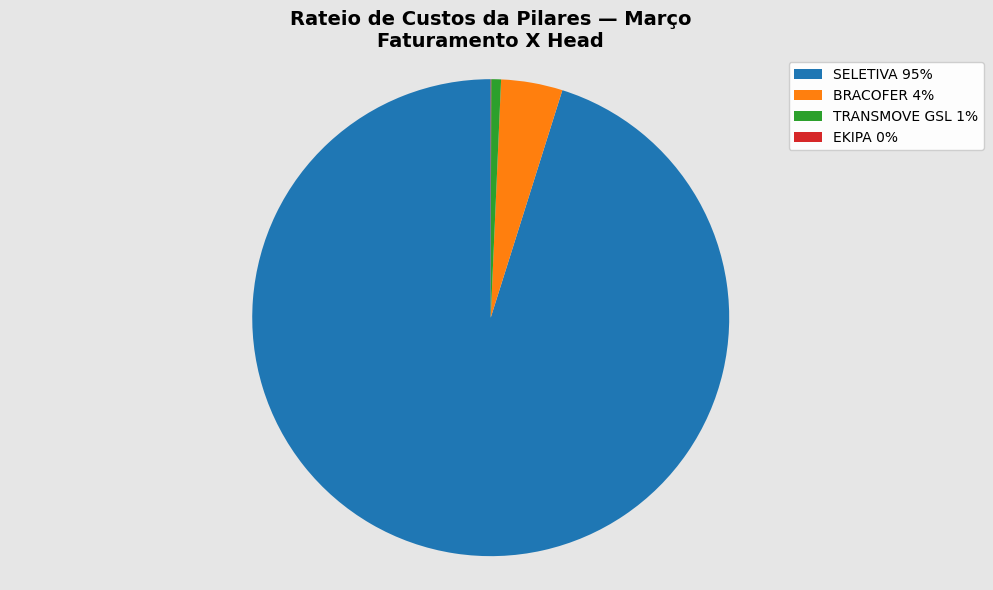

In [23]:
def plotar_pizza_rateio(
    tabela: pd.DataFrame,
    coluna_grupo: str = "grupo",
    coluna_valor: str = "valor_rateado",
    coluna_pct: str | None = "participacao_pct",
    titulo: str = "Rateio de Custos da Pilares\nFaturamento X Head",
):
    valores_abs = tabela[coluna_valor].abs()
    grupos = tabela[coluna_grupo]

    if coluna_pct and coluna_pct in tabela.columns:
        pcts = tabela[coluna_pct].astype(float)
    else:
        soma = float(valores_abs.sum())
        pcts = valores_abs / soma * 100 if soma else valores_abs * 0

    legend_labels = [f"{g} {p:.0f}%" for g, p in zip(grupos, pcts)]

    fig, ax = plt.subplots(figsize=(10, 6), facecolor="#e6e6e6")
    ax.set_facecolor("#e6e6e6")

    wedges, texts = ax.pie(
        valores_abs,
        labels=None,
        autopct=None,
        startangle=90,
        shadow=False,
    )

    ax.legend(
        wedges,
        legend_labels,
        loc="upper right",
        bbox_to_anchor=(1.02, 1.0),
        fontsize=10,
        framealpha=0.95,
    )
    ax.set_title(titulo, fontsize=14, fontweight="bold")
    ax.axis("equal")
    plt.tight_layout()
    return fig, ax


_titulo_pizza = f"Rateio de Custos da Pilares — {NOME_MES}\nFaturamento X Head"
fig, ax = plotar_pizza_rateio(resultado, titulo=_titulo_pizza)

In [24]:
# (Opcional) Salvar resultado e grafico — pastas na raiz do projeto:
#   outputs/tabelas/   (Excel)
#   outputs/graficos/  (PNG)
ROOT = _resolver_raiz_projeto()
DIR_OUTPUTS = ROOT / "outputs"
DIR_GRAFICOS = DIR_OUTPUTS / "graficos"
DIR_TABELAS = DIR_OUTPUTS / "tabelas"
for _d in (DIR_GRAFICOS, DIR_TABELAS):
    _d.mkdir(parents=True, exist_ok=True)

saida_excel = DIR_TABELAS / f"rateio_pilares_{NOME_MES}.xlsx"
saida_imagem = DIR_GRAFICOS / f"rateio_pilares_{NOME_MES}.png"

resultado.to_excel(saida_excel, index=False)
fig.savefig(saida_imagem, dpi=160, bbox_inches="tight")

print(f"Tabela salva em: {saida_excel.resolve()}")
print(f"Grafico salvo em: {saida_imagem.resolve()}")